In [16]:
import json, glob, os
import pandas as pd
import matplotlib.pyplot as plt

PERF_DIR = r"C:\Users\alexb\research\WEC-GRID\examples\benchmarking\perf"

def series_per_gen(df_backend):
    g = df_backend[df_backend.wec_enabled==False].sort_values("generators")
    return g["generators"].tolist(), g["time_per_gen_s_mean"].tolist()

def series_per_bus(df_backend):
    g = df_backend[df_backend.wec_enabled==False].sort_values("buses")
    return g["buses"].tolist(), g["time_per_bus_s_mean"].tolist()

rows = []
for f in glob.glob(os.path.join(PERF_DIR, "*.json")):
    with open(f, "r") as fh:
        data = json.load(fh)
    meta = data.get("meta", {})
    S    = data.get("summary", {})

    rows.append({
        "file": os.path.basename(f),
        "backend": (meta.get("backends") or ["?"])[0].lower(),
        "case": meta.get("case", ""),
        "wec_enabled": bool(meta.get("wec_enabled", False)),
        "buses":      S.get("buses_effective") or meta.get("buses_effective") or meta.get("buses_base"),
        "generators": S.get("generators_effective") or meta.get("generators_effective") or meta.get("generators_base"),

        # timing & memory
        "wall_time_s": S.get("wall_time_s_mean"),
        "peak_rss_gb": S.get("peak_rss_gb_mean"),

        # CPU utilization (this was missing)
        "avg_cpu_pct_mean": S.get("avg_cpu_pct_mean"),
        "avg_cpu_pct_p95":  S.get("avg_cpu_pct_p95"),

        # normalized metrics
        "time_per_bus_s_mean": S.get("time_per_bus_s_mean"),
        "time_per_bus_s_std":  S.get("time_per_bus_s_std"),
        "time_per_gen_s_mean": S.get("time_per_gen_s_mean"),
        "time_per_gen_s_std":  S.get("time_per_gen_s_std"),
        "time_per_wec_device_s_mean": S.get("time_per_wec_device_s_mean"),
        "time_per_wec_device_s_std":  S.get("time_per_wec_device_s_std"),
        
                # NEW: WEC counters for overhead join
        "total_wec_farms":   meta.get("total_wec_farms", S.get("total_wec_farms")),
        "total_wec_devices": meta.get("total_wec_devices", S.get("total_wec_devices")),
    })

df = pd.DataFrame(rows).dropna(subset=["backend","buses","wall_time_s"])
df["backend"] = df["backend"].str.lower()

# ensure numeric types (avoids plotting surprises)
for col in ["buses","generators","wall_time_s","peak_rss_gb",
            "avg_cpu_pct_mean","avg_cpu_pct_p95",
            "time_per_bus_s_mean","time_per_gen_s_mean"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = (df.sort_values(["backend","buses","wec_enabled","file"])
        .drop_duplicates(subset=["backend","buses","wec_enabled"], keep="last"))

df_psse  = df[df.backend=="psse"].sort_values(["wec_enabled","buses"])
df_pypsa = df[df.backend=="pypsa"].sort_values(["wec_enabled","buses"])

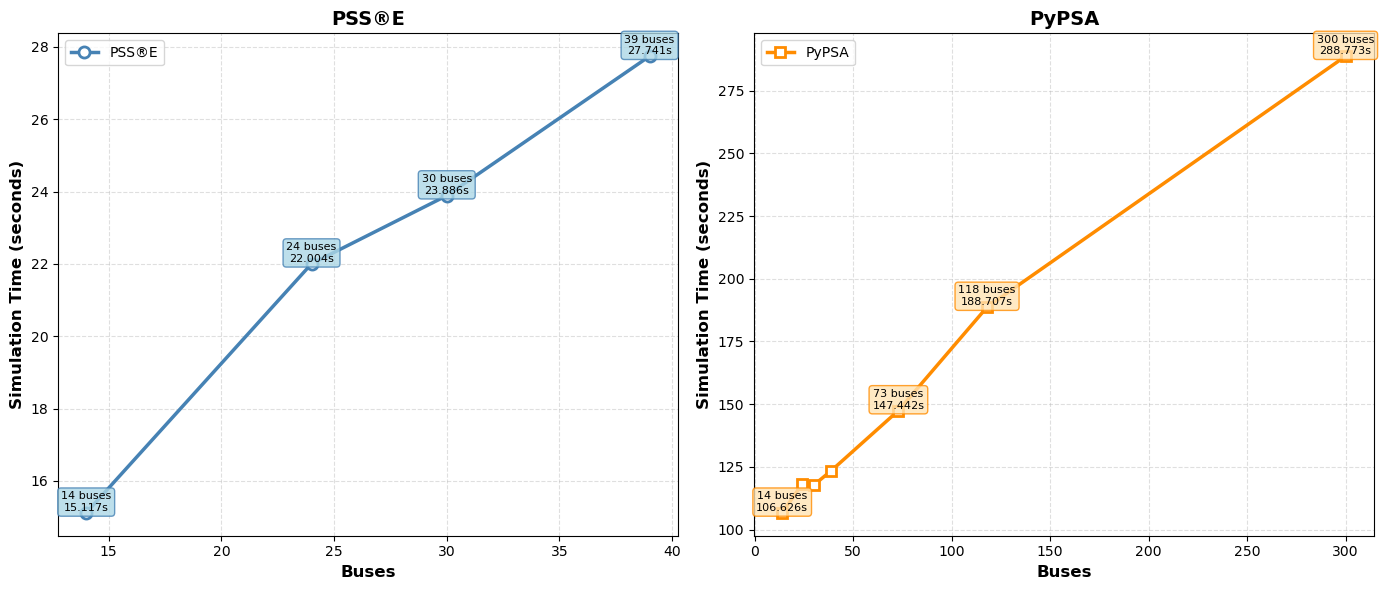

In [17]:
def series_total_time_vs_buses(df_backend):
    g = (df_backend[(df_backend["wec_enabled"]==False)]
                   .dropna(subset=["buses","wall_time_s"])
                   .sort_values("buses"))
    return g["buses"].tolist(), g["wall_time_s"].tolist()

# Extract series
x_psse, y_psse   = series_total_time_vs_buses(df_psse)
x_pypsa, y_pypsa = series_total_time_vs_buses(df_pypsa)



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# --- PSS®E panel ---
ax1.plot(x_psse, y_psse, 'o-', linewidth=2.5, markersize=8,
         color='steelblue', markerfacecolor='white', markeredgewidth=2, label="PSS®E")
for x, y in zip(x_psse, y_psse):
    ax1.text(x, y, f"{x} buses\n{y:.3f}s", fontsize=8,
             ha="center", va="bottom",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8, edgecolor="steelblue"))

ax1.set_title("PSS®E", fontsize=14, fontweight="bold")
ax1.set_xlabel("Buses", fontsize=12, fontweight="bold")
ax1.set_ylabel("Simulation Time (seconds)", fontsize=12, fontweight="bold")
ax1.grid(True, linestyle="--", alpha=0.4)
ax1.legend()

# --- PyPSA panel ---
ax2.plot(x_pypsa, y_pypsa, 's-', linewidth=2.5, markersize=7,
         color='darkorange', markerfacecolor='white', markeredgewidth=2, label="PyPSA")

# Only annotate selected points
annotate_points = [14, 73, 118, 300]
for x, y in zip(x_pypsa, y_pypsa):
    if x in annotate_points:
        ax2.text(x, y, f"{x} buses\n{y:.3f}s", fontsize=8,
                 ha="center", va="bottom",
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="moccasin", alpha=0.8, edgecolor="darkorange"))

ax2.set_title("PyPSA", fontsize=14, fontweight="bold")
ax2.set_xlabel("Buses", fontsize=12, fontweight="bold")
ax2.set_ylabel("Simulation Time (seconds)", fontsize=12, fontweight="bold")
ax2.grid(True, linestyle="--", alpha=0.4)
ax2.legend()

#fig.suptitle("Grid Size vs Simulation Time", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

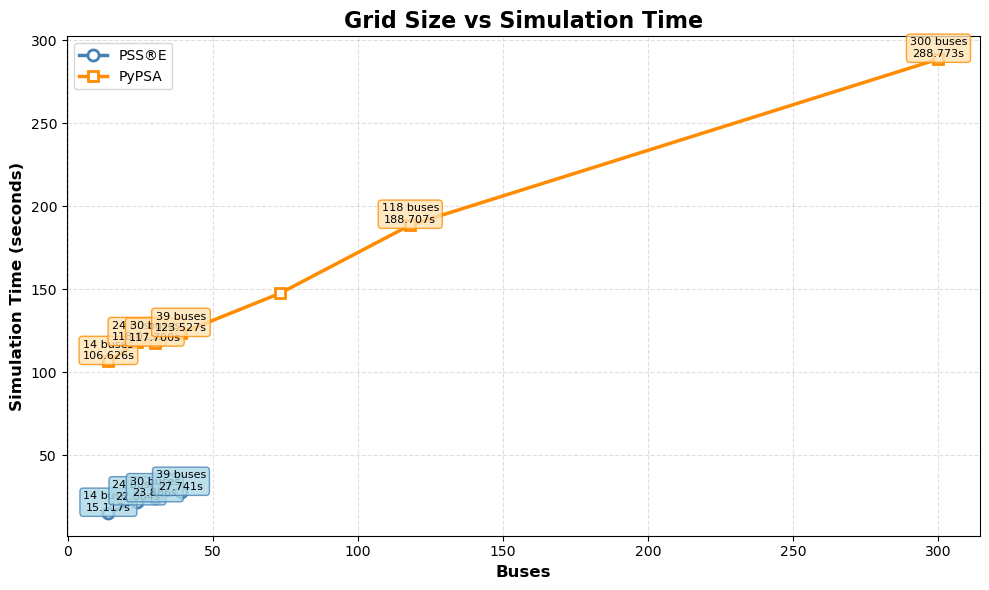

In [42]:
import matplotlib.pyplot as plt
import numpy as np

def series_total_time_vs_buses(df_backend):
    g = (df_backend[(df_backend["wec_enabled"]==False)]
                   .dropna(subset=["buses","wall_time_s"])
                   .sort_values("buses"))
    return g["buses"].tolist(), g["wall_time_s"].tolist()

# Extract series
x_psse, y_psse   = series_total_time_vs_buses(df_psse)
x_pypsa, y_pypsa = series_total_time_vs_buses(df_pypsa)

# --- Single figure ---
fig, ax = plt.subplots(figsize=(10, 6))

# PSS®E
ax.plot(x_psse, y_psse, 'o-', linewidth=2.5, markersize=8,
        color='steelblue', markerfacecolor='white', markeredgewidth=2, label="PSS®E")
for x, y in zip(x_psse, y_psse):
    ax.text(x, y, f"{x} buses\n{y:.3f}s", fontsize=8,
            ha="center", va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8, edgecolor="steelblue"))

# PyPSA
ax.plot(x_pypsa, y_pypsa, 's-', linewidth=2.5, markersize=7,
        color='darkorange', markerfacecolor='white', markeredgewidth=2, label="PyPSA")

annotate_points = [14, 24, 30, 39, 118, 300]
for x, y in zip(x_pypsa, y_pypsa):
    if x in annotate_points:
        ax.text(x, y, f"{x} buses\n{y:.3f}s", fontsize=8,
                ha="center", va="bottom",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="moccasin", alpha=0.8, edgecolor="darkorange"))

# Labels, grid, legend
ax.set_title("Grid Size vs Simulation Time", fontsize=16, fontweight="bold")
ax.set_xlabel("Buses", fontsize=12, fontweight="bold")
ax.set_ylabel("Simulation Time (seconds)", fontsize=12, fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()

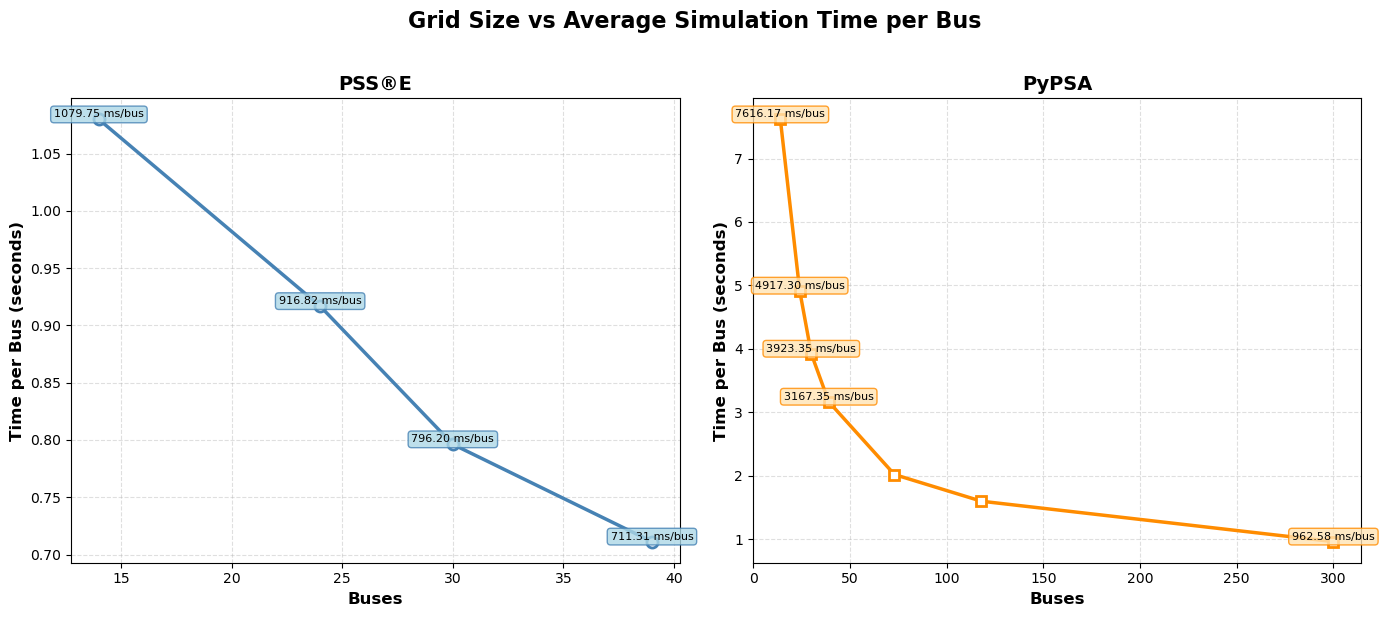

In [43]:

# Extract series
x_psse, y_psse = series_per_bus(df_psse)
x_pypsa, y_pypsa = series_per_bus(df_pypsa)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- PSS®E (ms/bus labels) ---
ax1.plot(x_psse, y_psse, 'o-', linewidth=2.5, markersize=8,
         color='steelblue', markerfacecolor='white', markeredgewidth=2, label="PSS®E")
for x, y in zip(x_psse, y_psse):
    ax1.text(x, y, f"{(y*1000):.2f} ms/bus", fontsize=8,
             ha="center", va="bottom",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8, edgecolor="steelblue"))

ax1.set_title("PSS®E", fontsize=14, fontweight="bold")
ax1.set_xlabel("Buses", fontsize=12, fontweight="bold")
ax1.set_ylabel("Time per Bus (seconds)", fontsize=12, fontweight="bold")
ax1.grid(True, linestyle="--", alpha=0.4)

# --- PyPSA (annotate only a few points) ---
ax2.plot(x_pypsa, y_pypsa, 's-', linewidth=2.5, markersize=7,
         color='darkorange', markerfacecolor='white', markeredgewidth=2, label="PyPSA")

annotate_points = {14, 24, 30, 39, 300}#, 118, 300}
for x, y in zip(x_pypsa, y_pypsa):
    if x in annotate_points:
        ax2.text(x, y, f"{(y*1000):.2f} ms/bus", fontsize=8,
                 ha="center", va="bottom",
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="moccasin", alpha=0.8, edgecolor="darkorange"))

ax2.set_title("PyPSA", fontsize=14, fontweight="bold")
ax2.set_xlabel("Buses", fontsize=12, fontweight="bold")
ax2.set_ylabel("Time per Bus (seconds)", fontsize=12, fontweight="bold")
ax2.grid(True, linestyle="--", alpha=0.4)

fig.suptitle("Grid Size vs Average Simulation Time per Bus", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

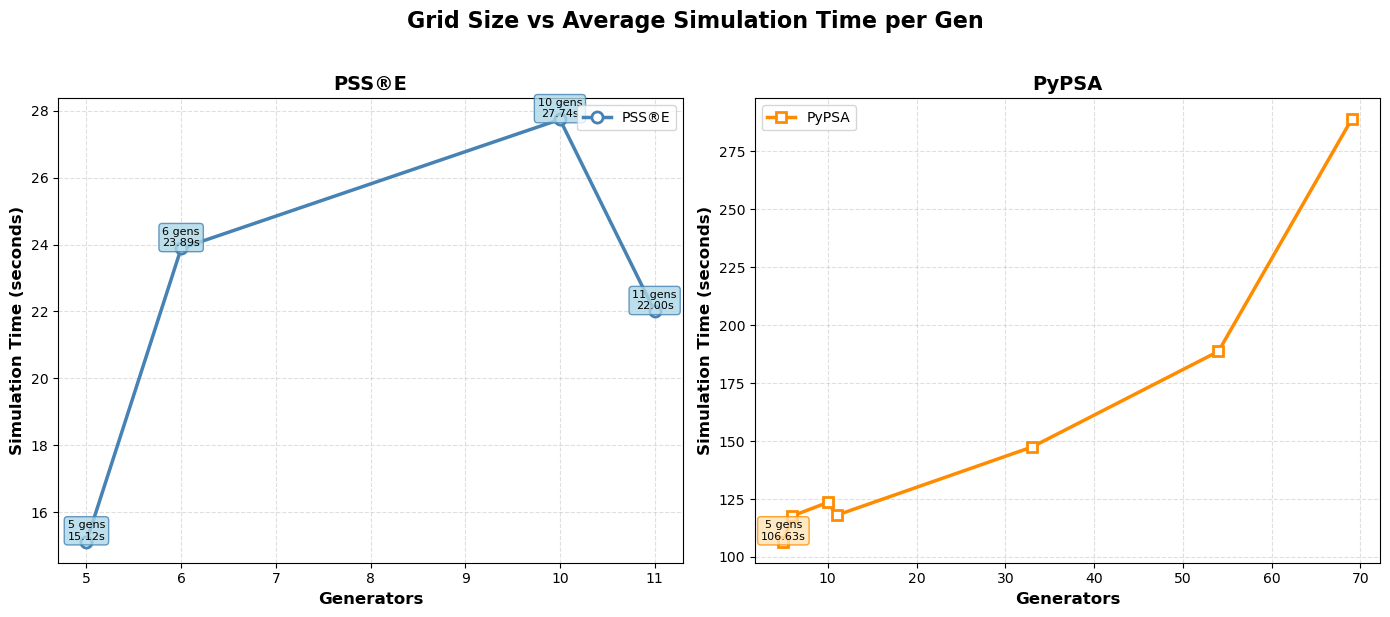

In [44]:
import matplotlib.pyplot as plt

def series_vs_gen(df_backend):
    g = df_backend[df_backend.wec_enabled==False].sort_values("generators")
    return g["generators"].tolist(), g["wall_time_s"].tolist()

# Extract PSS®E and PyPSA
x_psse, y_psse   = series_vs_gen(df_psse)
x_pypsa, y_pypsa = series_vs_gen(df_pypsa)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# --- PSS®E panel ---
ax1.plot(x_psse, y_psse, 'o-', linewidth=2.5, markersize=8,
         color='steelblue', markerfacecolor='white', markeredgewidth=2, label="PSS®E")
for x, y in zip(x_psse, y_psse):
    ax1.text(x, y, f"{x} gens\n{y:.2f}s", fontsize=8,
             ha="center", va="bottom",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8, edgecolor="steelblue"))

ax1.set_title("PSS®E", fontsize=14, fontweight="bold")
ax1.set_xlabel("Generators", fontsize=12, fontweight="bold")
ax1.set_ylabel("Simulation Time (seconds)", fontsize=12, fontweight="bold")
ax1.grid(True, linestyle="--", alpha=0.4)
ax1.legend()

# --- PyPSA panel ---
ax2.plot(x_pypsa, y_pypsa, 's-', linewidth=2.5, markersize=7,
         color='darkorange', markerfacecolor='white', markeredgewidth=2, label="PyPSA")

# Annotate just a few for clarity
annotate_gens = [5, ]
for x, y in zip(x_pypsa, y_pypsa):
    if x in annotate_gens:
        ax2.text(x, y, f"{x} gens\n{y:.2f}s", fontsize=8,
                 ha="center", va="bottom",
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="moccasin", alpha=0.8, edgecolor="darkorange"))

ax2.set_title("PyPSA", fontsize=14, fontweight="bold")
ax2.set_xlabel("Generators", fontsize=12, fontweight="bold")
ax2.set_ylabel("Simulation Time (seconds)", fontsize=12, fontweight="bold")
ax2.grid(True, linestyle="--", alpha=0.4)
ax2.legend()

fig.suptitle("Grid Size vs Average Simulation Time per Gen", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

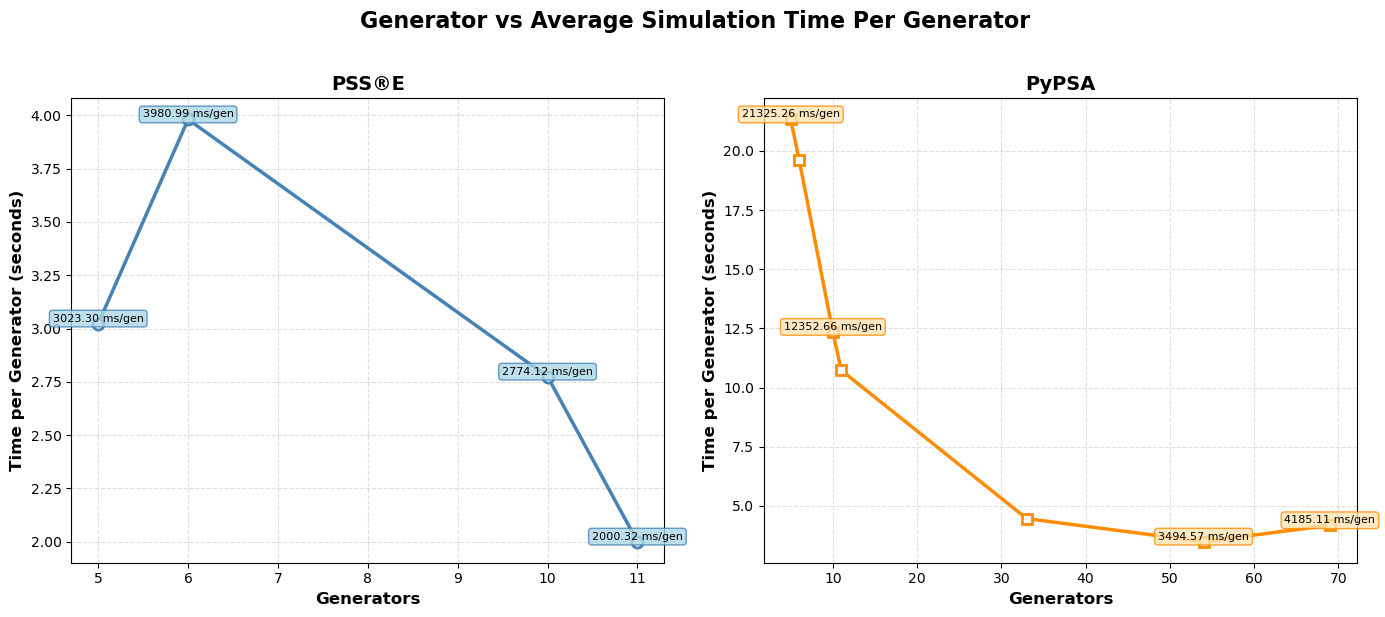

In [45]:
xg_psse, yg_psse = series_per_gen(df_psse)
xg_pypsa, yg_pypsa = series_per_gen(df_pypsa)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# --- PSS®E panel (all points annotated) ---
ax1.plot(xg_psse, yg_psse, 'o-', linewidth=2.5, markersize=8,
         color='steelblue', markerfacecolor='white', markeredgewidth=2, label="PSS®E")
for x, y in zip(xg_psse, yg_psse):
    ax1.text(x, y, f"{(y*1000):.2f} ms/gen", fontsize=8,
             ha="center", va="bottom",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8, edgecolor="steelblue"))

ax1.set_title("PSS®E", fontsize=14, fontweight="bold")
ax1.set_xlabel("Generators", fontsize=12, fontweight="bold")
ax1.set_ylabel("Time per Generator (seconds)", fontsize=12, fontweight="bold")
ax1.grid(True, linestyle="--", alpha=0.4)

# --- PyPSA panel (annotate selected points to avoid overlap) ---
ax2.plot(xg_pypsa, yg_pypsa, 's-', linewidth=2.5, markersize=7,
         color='darkorange', markerfacecolor='white', markeredgewidth=2, label="PyPSA")

# choose representative gen counts to label (adjust based on your data)
annotate_gens = {xg_pypsa[0], xg_pypsa[min(2, len(xg_pypsa)-1)],
                 xg_pypsa[-2] if len(xg_pypsa) > 2 else xg_pypsa[-1],
                 xg_pypsa[-1]}
for x, y in zip(xg_pypsa, yg_pypsa):
    if x in annotate_gens:
        ax2.text(x, y, f"{(y*1000):.2f} ms/gen", fontsize=8,
                 ha="center", va="bottom",
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="moccasin", alpha=0.8, edgecolor="darkorange"))

ax2.set_title("PyPSA", fontsize=14, fontweight="bold")
ax2.set_xlabel("Generators", fontsize=12, fontweight="bold")
ax2.set_ylabel("Time per Generator (seconds)", fontsize=12, fontweight="bold")
ax2.grid(True, linestyle="--", alpha=0.4)

fig.suptitle("Generator vs Average Simulation Time Per Generator", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

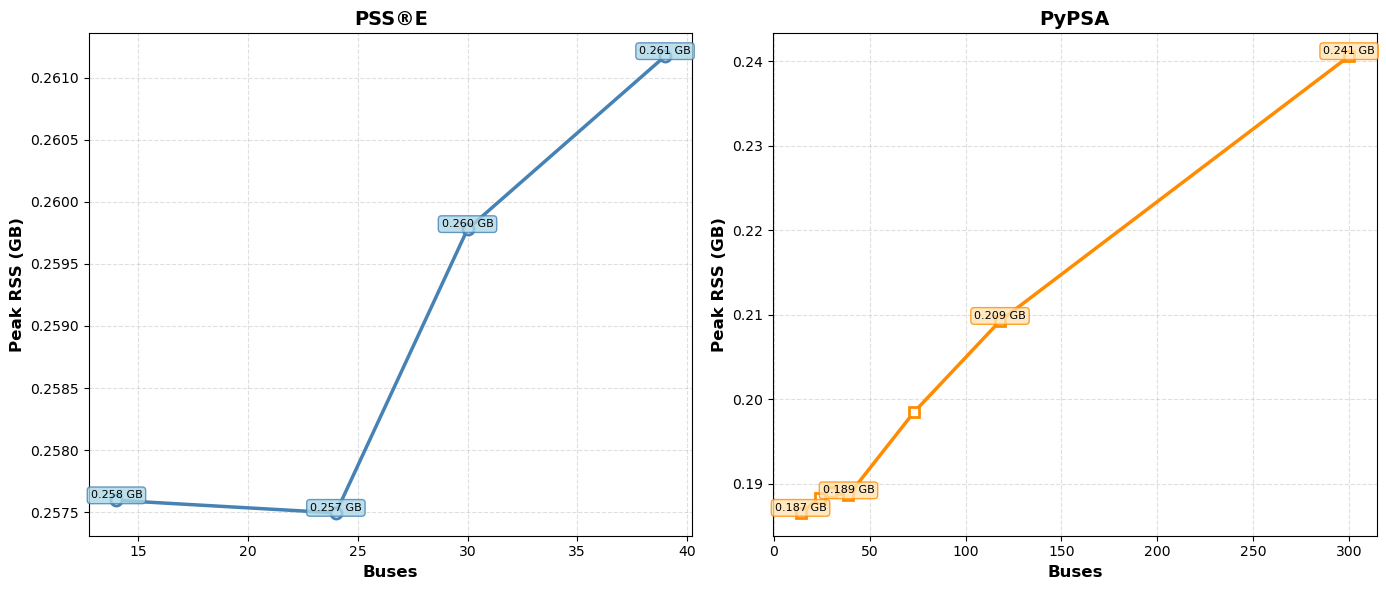

In [46]:
import matplotlib.pyplot as plt
import numpy as np

def series_mem(df_backend):
    g = df_backend[df_backend.wec_enabled==False].sort_values("buses")
    return g["buses"].tolist(), g["peak_rss_gb"].tolist()

x_psse, y_psse = series_mem(df_psse)
x_pypsa, y_pypsa = series_mem(df_pypsa)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- PSS®E ---
ax1.plot(x_psse, y_psse, 'o-', linewidth=2.5, markersize=8,
         color='steelblue', markerfacecolor='white', markeredgewidth=2, label="PSS®E")
for x, y in zip(x_psse, y_psse):
    ax1.text(x, y, f"{y:.3f} GB", fontsize=8, ha="center", va="bottom",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8, edgecolor="steelblue"))
ax1.set_title("PSS®E", fontsize=14, fontweight="bold")
ax1.set_xlabel("Buses", fontsize=12, fontweight="bold")
ax1.set_ylabel("Peak RSS (GB)", fontsize=12, fontweight="bold")
ax1.grid(True, linestyle="--", alpha=0.4)

# --- PyPSA ---
ax2.plot(x_pypsa, y_pypsa, 's-', linewidth=2.5, markersize=7,
         color='darkorange', markerfacecolor='white', markeredgewidth=2, label="PyPSA")
for x, y in zip(x_pypsa, y_pypsa):
    if x in {14, 39, 118, 300}:  # annotate a few to avoid clutter
        ax2.text(x, y, f"{y:.3f} GB", fontsize=8, ha="center", va="bottom",
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="moccasin", alpha=0.8, edgecolor="darkorange"))
ax2.set_title("PyPSA", fontsize=14, fontweight="bold")
ax2.set_xlabel("Buses", fontsize=12, fontweight="bold")
ax2.set_ylabel("Peak RSS (GB)", fontsize=12, fontweight="bold")
ax2.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

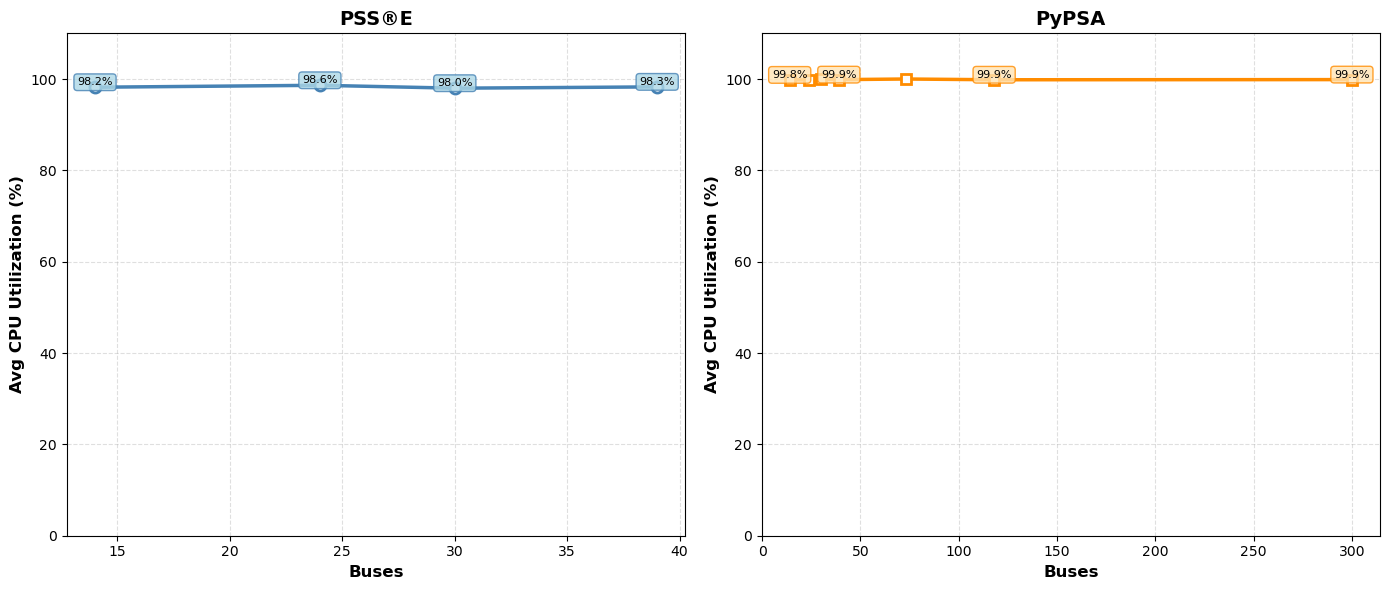

In [47]:
import matplotlib.pyplot as plt
import numpy as np

def series_cpu(dfx):
    g = dfx[(dfx.wec_enabled==False) & dfx["avg_cpu_pct_mean"].notna()].sort_values("buses")
    return g["buses"].tolist(), g["avg_cpu_pct_mean"].tolist()

x_psse, y_psse = series_cpu(df_psse)
x_pypsa, y_pypsa = series_cpu(df_pypsa)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- PSS®E ---
ax1.plot(x_psse, y_psse, 'o-', linewidth=2.5, markersize=8,
         color='steelblue', markerfacecolor='white', markeredgewidth=2, label="PSS®E")
for x, y in zip(x_psse, y_psse):
    ax1.text(x, y, f"{y:.1f}%", fontsize=8, ha="center", va="bottom",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8, edgecolor="steelblue"))
ax1.set_title("PSS®E", fontsize=14, fontweight="bold")
ax1.set_xlabel("Buses", fontsize=12, fontweight="bold")
ax1.set_ylabel("Avg CPU Utilization (%)", fontsize=12, fontweight="bold")
ax1.set_ylim(0, max(y_psse + [100]) * 1.1)  # keep within a nice range
ax1.grid(True, linestyle="--", alpha=0.4)

# --- PyPSA ---
ax2.plot(x_pypsa, y_pypsa, 's-', linewidth=2.5, markersize=7,
         color='darkorange', markerfacecolor='white', markeredgewidth=2, label="PyPSA")
for x, y in zip(x_pypsa, y_pypsa):
    if x in {14, 39, 118, 300}:
        ax2.text(x, y, f"{y:.1f}%", fontsize=8, ha="center", va="bottom",
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="moccasin", alpha=0.8, edgecolor="darkorange"))
ax2.set_title("PyPSA", fontsize=14, fontweight="bold")
ax2.set_xlabel("Buses", fontsize=12, fontweight="bold")
ax2.set_ylabel("Avg CPU Utilization (%)", fontsize=12, fontweight="bold")
ax2.set_ylim(0, max(y_pypsa + [100]) * 1.1)
ax2.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [48]:
import numpy as np
import pandas as pd

def _clean_baseline(dfx):
    """Baseline rows with numeric fields, sorted by buses."""
    cols = ["case","buses","generators","wall_time_s","peak_rss_gb","avg_cpu_pct_mean",
            "time_per_bus_s_mean","time_per_gen_s_mean"]
    g = (dfx[(dfx["wec_enabled"]==False)]
           .dropna(subset=["buses","wall_time_s"])
           .copy())
    for c in cols:
        if c in g.columns:
            g[c] = pd.to_numeric(g[c], errors="coerce")
    return g.sort_values("buses")

def _linfit(x, y):
    """Simple linear fit + R² (y ~ a*x + b). Returns (slope a, intercept b, r2)."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 2:
        return np.nan, np.nan, np.nan
    a, b = np.polyfit(x, y, 1)
    y_hat = a*x + b
    ss_res = np.sum((y - y_hat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    return a, b, r2

def scaling_summary(dfx, backend_name):
    """
    Produces a compact summary of how the backend scales with grid size:
      - slope(sec/bus) & R² for total sim time vs buses
      - slope(GB/bus)  & R² for peak RSS vs buses
      - mean CPU utilization across baselines
      - mean time/bus and time/gen (if present)
    Returns a 1-row DataFrame.
    """
    g = _clean_baseline(dfx)

    # Totals vs buses
    a_t, b_t, r2_t = _linfit(g["buses"], g["wall_time_s"])

    # Memory vs buses
    if "peak_rss_gb" in g.columns and g["peak_rss_gb"].notna().any():
        a_m, b_m, r2_m = _linfit(g["buses"], g["peak_rss_gb"])
    else:
        a_m = b_m = r2_m = np.nan

    row = {
        "backend": backend_name,
        "n_points": len(g),
        "buses_min": g["buses"].min() if len(g) else np.nan,
        "buses_max": g["buses"].max() if len(g) else np.nan,

        # time scaling
        "slope_sec_per_bus": a_t,        # seconds added per bus
        "intercept_sec": b_t,
        "r2_time_vs_buses": r2_t,

        # memory scaling
        "slope_GB_per_bus": a_m,         # GB added per bus
        "intercept_GB": b_m,
        "r2_mem_vs_buses": r2_m,

        # utilization & normalized means
        "mean_cpu_pct": g["avg_cpu_pct_mean"].mean() if "avg_cpu_pct_mean" in g else np.nan,
        "mean_time_per_bus_s": g["time_per_bus_s_mean"].mean() if "time_per_bus_s_mean" in g else np.nan,
        "mean_time_per_gen_s": g["time_per_gen_s_mean"].mean() if "time_per_gen_s_mean" in g else np.nan,
    }
    return pd.DataFrame([row])

# ---- Run summaries for both backends ----
summ_psse  = scaling_summary(df_psse,  "psse")
summ_pypsa = scaling_summary(df_pypsa, "pypsa")
scaling_table = pd.concat([summ_psse, summ_pypsa], ignore_index=True)

display(scaling_table.style.format({
    "slope_sec_per_bus": "{:.3f}",
    "intercept_sec": "{:.3f}",
    "r2_time_vs_buses": "{:.3f}",
    "slope_GB_per_bus": "{:.6f}",
    "intercept_GB": "{:.3f}",
    "r2_mem_vs_buses": "{:.3f}",
    "mean_cpu_pct": "{:.2f}",
    "mean_time_per_bus_s": "{:.3f}",
    "mean_time_per_gen_s": "{:.3f}",
}))

,backend,n_points,buses_min,buses_max,slope_sec_per_bus,intercept_sec,r2_time_vs_buses,slope_GB_per_bus,intercept_GB,r2_mem_vs_buses,mean_cpu_pct,mean_time_per_bus_s,mean_time_per_gen_s
0,psse,4,14,39,0.496,8.906,0.973,0.000155,0.255,0.828,98.27,0.876,2.945
1,pypsa,7,14,300,0.638,101.318,0.992,0.000193,0.184,0.993,99.90,3.458,10.882


In [49]:
def wec_overhead_table(df_all, backend_name):
    """
    Compares baseline vs WEC-enabled runs per CASE for a given backend.
    Matches rows by 'case'. Returns a table with deltas and an overall average.
    """
    dfx = df_all[df_all["backend"]==backend_name].copy()

    base = (dfx[dfx["wec_enabled"]==False]
              .set_index("case")[["buses","generators","wall_time_s","peak_rss_gb",
                                   "time_per_bus_s_mean","time_per_gen_s_mean"]]
              .rename(columns={
                  "buses":"buses_base","generators":"gens_base",
                  "wall_time_s":"time_base_s","peak_rss_gb":"rss_base_gb",
                  "time_per_bus_s_mean":"tpb_base_s","time_per_gen_s_mean":"tpg_base_s"
              }))

    wec  = (dfx[dfx["wec_enabled"]==True]
              .set_index("case")[["buses","generators","wall_time_s","peak_rss_gb",
                                   "time_per_bus_s_mean","time_per_gen_s_mean","total_wec_farms","total_wec_devices"]]
              .rename(columns={
                  "buses":"buses_wec","generators":"gens_wec",
                  "wall_time_s":"time_wec_s","peak_rss_gb":"rss_wec_gb",
                  "time_per_bus_s_mean":"tpb_wec_s","time_per_gen_s_mean":"tpg_wec_s"
              }))

    tbl = base.join(wec, how="inner").reset_index()

    # compute deltas
    tbl["Δbuses"]        = tbl["buses_wec"] - tbl["buses_base"]
    tbl["Δgens"]         = tbl["gens_wec"]  - tbl["gens_base"]
    tbl["Δtime_s"]       = tbl["time_wec_s"] - tbl["time_base_s"]
    tbl["Δtime_%"]       = 100.0 * tbl["Δtime_s"] / tbl["time_base_s"]
    tbl["Δrss_GB"]       = tbl["rss_wec_gb"] - tbl["rss_base_gb"]
    tbl["Δtpb_s"]        = tbl["tpb_wec_s"] - tbl["tpb_base_s"]
    tbl["Δtpg_s"]        = tbl["tpg_wec_s"] - tbl["tpg_base_s"]

    # Order columns
    cols = ["case",
            "buses_base","buses_wec","Δbuses",
            "gens_base","gens_wec","Δgens",
            "time_base_s","time_wec_s","Δtime_s","Δtime_%",
            "rss_base_gb","rss_wec_gb","Δrss_GB",
            "tpb_base_s","tpb_wec_s","Δtpb_s",
            "tpg_base_s","tpg_wec_s","Δtpg_s"]
    tbl = tbl[cols]

    # overall averages
    overall = pd.DataFrame([{
        "case": "(mean across cases)",
        "buses_base": tbl["buses_base"].mean(),
        "buses_wec":  tbl["buses_wec"].mean(),
        "Δbuses":     tbl["Δbuses"].mean(),
        "gens_base":  tbl["gens_base"].mean(),
        "gens_wec":   tbl["gens_wec"].mean(),
        "Δgens":      tbl["Δgens"].mean(),
        "time_base_s": tbl["time_base_s"].mean(),
        "time_wec_s":  tbl["time_wec_s"].mean(),
        "Δtime_s":     tbl["Δtime_s"].mean(),
        "Δtime_%":     tbl["Δtime_%"].mean(),
        "rss_base_gb": tbl["rss_base_gb"].mean(),
        "rss_wec_gb":  tbl["rss_wec_gb"].mean(),
        "Δrss_GB":     tbl["Δrss_GB"].mean(),
        "tpb_base_s":  tbl["tpb_base_s"].mean(),
        "tpb_wec_s":   tbl["tpb_wec_s"].mean(),
        "Δtpb_s":      tbl["Δtpb_s"].mean(),
        "tpg_base_s":  tbl["tpg_base_s"].mean(),
        "tpg_wec_s":   tbl["tpg_wec_s"].mean(),
        "Δtpg_s":      tbl["Δtpg_s"].mean(),
    }])

    return tbl, overall

# ---- Build tables for each backend ----
tbl_psse, overall_psse   = wec_overhead_table(df, "psse")
tbl_pypsa, overall_pypsa = wec_overhead_table(df, "pypsa")

print("PSS®E — WEC overhead per case")
display(tbl_psse.style.format({
    "time_base_s":"{:.3f}", "time_wec_s":"{:.3f}", "Δtime_s":"{:.3f}", "Δtime_%":"{:.1f}",
    "rss_base_gb":"{:.3f}", "rss_wec_gb":"{:.3f}", "Δrss_GB":"{:.3f}",
    "tpb_base_s":"{:.3f}", "tpb_wec_s":"{:.3f}", "Δtpb_s":"{:.3f}",
    "tpg_base_s":"{:.3f}", "tpg_wec_s":"{:.3f}", "Δtpg_s":"{:.3f}"
}))

print("\nPSS®E — overall averages")
display(overall_psse.style.format({
    "time_base_s":"{:.3f}", "time_wec_s":"{:.3f}", "Δtime_s":"{:.3f}", "Δtime_%":"{:.1f}",
    "rss_base_gb":"{:.3f}", "rss_wec_gb":"{:.3f}", "Δrss_GB":"{:.3f}",
    "tpb_base_s":"{:.3f}", "tpb_wec_s":"{:.3f}", "Δtpb_s":"{:.3f}",
    "tpg_base_s":"{:.3f}", "tpg_wec_s":"{:.3f}", "Δtpg_s":"{:.3f}"
}))

print("\nPyPSA — WEC overhead per case")
display(tbl_pypsa.style.format({
    "time_base_s":"{:.3f}", "time_wec_s":"{:.3f}", "Δtime_s":"{:.3f}", "Δtime_%":"{:.1f}",
    "rss_base_gb":"{:.3f}", "rss_wec_gb":"{:.3f}", "Δrss_GB":"{:.3f}",
    "tpb_base_s":"{:.3f}", "tpb_wec_s":"{:.3f}", "Δtpb_s":"{:.3f}",
    "tpg_base_s":"{:.3f}", "tpg_wec_s":"{:.3f}", "Δtpg_s":"{:.3f}"
}))

print("\nPyPSA — overall averages")
display(overall_pypsa.style.format({
    "time_base_s":"{:.3f}", "time_wec_s":"{:.3f}", "Δtime_s":"{:.3f}", "Δtime_%":"{:.1f}",
    "rss_base_gb":"{:.3f}", "rss_wec_gb":"{:.3f}", "Δrss_GB":"{:.3f}",
    "tpb_base_s":"{:.3f}", "tpb_wec_s":"{:.3f}", "Δtpb_s":"{:.3f}",
    "tpg_base_s":"{:.3f}", "tpg_wec_s":"{:.3f}", "Δtpg_s":"{:.3f}"
}))

PSS®E — WEC overhead per case


,case,buses_base,buses_wec,Δbuses,gens_base,gens_wec,Δgens,time_base_s,time_wec_s,Δtime_s,Δtime_%,rss_base_gb,rss_wec_gb,Δrss_GB,tpb_base_s,tpb_wec_s,Δtpb_s,tpg_base_s,tpg_wec_s,Δtpg_s
0,..\grid_models\IEEE_14_bus.RAW,14,15,1,5,6,1,15.117,16.136,1.019,6.7,0.258,0.261,0.003,1.080,1.076,-0.004,3.023,2.689,-0.334
1,..\grid_models\IEEE_24_bus.RAW,24,25,1,11,12,1,22.004,22.523,0.520,2.4,0.257,0.261,0.004,0.917,0.901,-0.016,2.000,1.877,-0.123
2,..\grid_models\IEEE_30_bus.RAW,30,31,1,6,7,1,23.886,24.704,0.818,3.4,0.260,0.262,0.003,0.796,0.797,0.001,3.981,3.529,-0.452
3,..\grid_models\IEEE_39_bus.RAW,39,40,1,10,11,1,27.741,28.051,0.310,1.1,0.261,0.263,0.002,0.711,0.701,-0.010,2.774,2.550,-0.224



PSS®E — overall averages


,case,buses_base,buses_wec,Δbuses,gens_base,gens_wec,Δgens,time_base_s,time_wec_s,Δtime_s,Δtime_%,rss_base_gb,rss_wec_gb,Δrss_GB,tpb_base_s,tpb_wec_s,Δtpb_s,tpg_base_s,tpg_wec_s,Δtpg_s
0,(mean across cases),26.750000,27.750000,1.000000,8.000000,9.000000,1.000000,22.187,22.853,0.667,3.4,0.259,0.262,0.003,0.876,0.869,-0.007,2.945,2.661,-0.283



PyPSA — WEC overhead per case


,case,buses_base,buses_wec,Δbuses,gens_base,gens_wec,Δgens,time_base_s,time_wec_s,Δtime_s,Δtime_%,rss_base_gb,rss_wec_gb,Δrss_GB,tpb_base_s,tpb_wec_s,Δtpb_s,tpg_base_s,tpg_wec_s,Δtpg_s
0,..\grid_models\IEEE_14_bus.RAW,14,15,1,5,6,1,106.626,108.176,1.549,1.5,0.187,0.187,0.001,7.616,7.212,-0.404,21.325,18.029,-3.296
1,..\grid_models\IEEE_24_bus.RAW,24,25,1,11,12,1,118.015,118.876,0.861,0.7,0.188,0.187,-0.001,4.917,4.755,-0.162,10.729,9.906,-0.822
2,..\grid_models\IEEE_30_bus.RAW,30,31,1,6,7,1,117.700,118.929,1.229,1.0,0.189,0.189,-0.000,3.923,3.836,-0.087,19.617,16.990,-2.627
3,..\grid_models\IEEE_39_bus.RAW,39,40,1,10,11,1,123.527,126.181,2.654,2.1,0.189,0.191,0.002,3.167,3.155,-0.013,12.353,11.471,-0.882



PyPSA — overall averages


,case,buses_base,buses_wec,Δbuses,gens_base,gens_wec,Δgens,time_base_s,time_wec_s,Δtime_s,Δtime_%,rss_base_gb,rss_wec_gb,Δrss_GB,tpb_base_s,tpb_wec_s,Δtpb_s,tpg_base_s,tpg_wec_s,Δtpg_s
0,(mean across cases),26.750000,27.750000,1.000000,8.000000,9.000000,1.000000,116.467,118.040,1.573,1.3,0.188,0.189,0.000,4.906,4.739,-0.167,16.006,14.099,-1.907


  backend    config  wall_time_s_mean
0   PSS®E  baseline         27.741194
1   PSS®E     wec_1         36.205459
2   PSS®E     wec_2         35.436314
3   PSS®E     wec_3         35.631135
0   PyPSA  baseline        123.526575
1   PyPSA     wec_1        127.592150
2   PyPSA     wec_2        129.435010
3   PyPSA     wec_3        131.168357


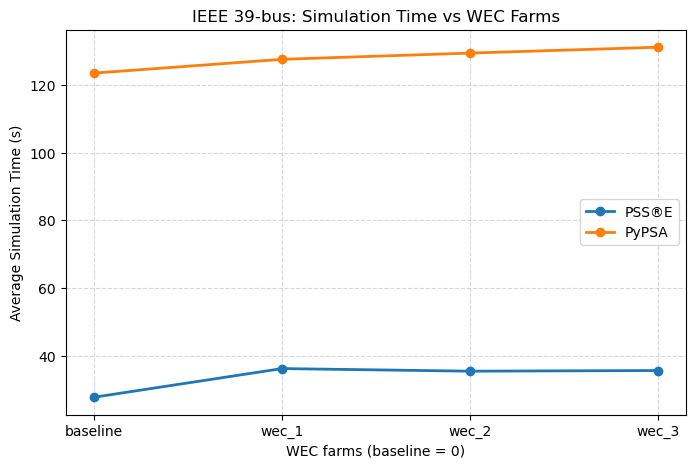

In [1]:
import json, os, pandas as pd
import matplotlib.pyplot as plt

PERF_DIR = r"C:\Users\alexb\research\WEC-GRID\examples\benchmarking\perf"

def load_summary(fname):
    with open(os.path.join(PERF_DIR, fname), "r") as fh:
        data = json.load(fh)
    return data["summary"]["wall_time_s_mean"]

# --- Filenames ---
psse_files  = {
    "baseline": "psse_IEEE_39_bus_baseline.json",
    "wec_1":    "psse_IEEE_39_bus_wec_1.json",
    "wec_2":    "psse_IEEE_39_bus_wec_2.json",
    "wec_3":    "psse_IEEE_39_bus_wec_3.json",
}

pypsa_files = {
    "baseline": "pypsa_IEEE_39_bus_baseline.json",
    "wec_1":    "pypsa_IEEE_39_bus_wec_1.json",
    "wec_2":    "pypsa_IEEE_39_bus_wec_2.json",
    "wec_3":    "pypsa_IEEE_39_bus_wec_3.json",
}

# --- Load into DataFrames ---
def collect_backend(files_dict, backend):
    rows = []
    for label, fname in files_dict.items():
        if os.path.exists(os.path.join(PERF_DIR, fname)):
            wt = load_summary(fname)
            rows.append({"backend": backend, "config": label, "wall_time_s_mean": wt})
    return pd.DataFrame(rows)

df_psse  = collect_backend(psse_files, "PSS®E")
df_pypsa = collect_backend(pypsa_files, "PyPSA")
df_all   = pd.concat([df_psse, df_pypsa])

print(df_all)

# --- Plot ---
fig, ax = plt.subplots(figsize=(8,5))
for backend, g in df_all.groupby("backend"):
    ax.plot(g["config"], g["wall_time_s_mean"], marker="o", linewidth=2, label=backend)

ax.set_title("IEEE 39-bus: Simulation Time vs WEC Farms")
ax.set_xlabel("WEC farms (baseline = 0)")
ax.set_ylabel("Average Simulation Time (s)")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
plt.show()

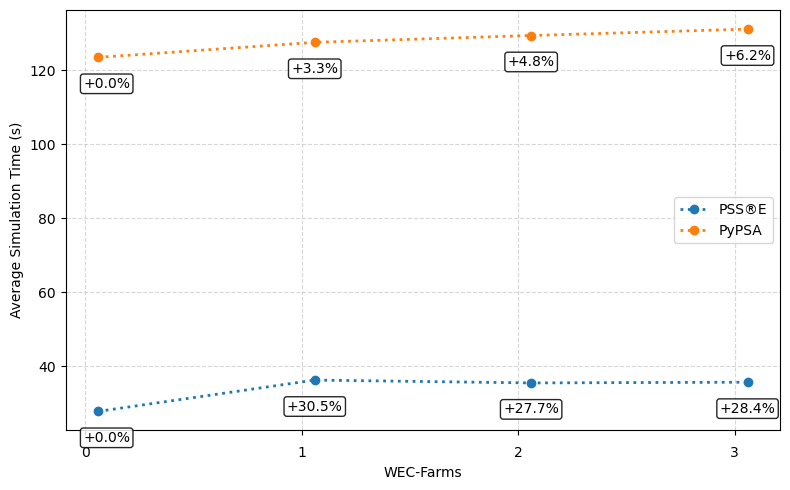

In [18]:
fig, ax = plt.subplots(figsize=(8,5))

# map configs to numeric 0..3
x_map = {"baseline": 0, "wec_1": 1, "wec_2": 2, "wec_3": 3}

for backend, g in df_all.groupby("backend"):
    xs_raw = [x_map[c] for c in g["config"]]
    ys     = g["wall_time_s_mean"].tolist()

    # small horizontal jitter so baseline tick "0" isn't covered
    jitter = -0.06 if backend.lower() == "psse" else +0.06
    xs = [x + jitter for x in xs_raw]

    ax.plot(xs, ys, marker="o", linestyle=":", linewidth=2, label=backend, zorder=2)

    # annotations: nudge up for PSS®E, down for PyPSA, and add slight x offset at baseline
    for xr, xj, y, dt in zip(xs_raw, xs, ys, g["Δtime_%"]):
        if backend.lower() == "psse":
            dx = -6 if xr == 0 else 0   # baseline: shift left a bit
            dy = 10
            va, ha = "bottom", "center"
        else:
            dx = 6 if xr == 0 else 0    # baseline: shift right a bit
            dy = -14
            va, ha = "top", "center"

        ax.annotate(f"+{dt:.1f}%", xy=(xj, y), xytext=(dx, dy),
                    textcoords="offset points", ha=ha, va=va,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85),
                    zorder=3, clip_on=False)

# cosmetics
#ax.set_title("IEEE 39-bus: Simulation Time vs WEC Farms")
ax.set_xlabel("WEC-Farms")
ax.set_ylabel("Average Simulation Time (s)")
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(["0", "1", "2", "3"])
ax.tick_params(axis="x", pad=8)            # push tick labels away from axis a bit
ax.grid(True, linestyle="--", alpha=0.5, zorder=1)
ax.legend()
plt.tight_layout()
plt.show()